# 10 — Walk-forward validation (is the edge real, or was one window lucky?)

**Input:** `data/processed/btc_features.csv` (from notebook 05)
**Goal:** stress-test everything notebooks 06–08 found on a *single* chronological split. One
split can flatter (or unfairly punish) a model. Walk-forward validation slides the train/test
boundary through time and refits at every step, so instead of one accuracy number we get a
**distribution across many out-of-sample folds** — and instead of one backtest we get a backtest
over the *entire* out-of-sample span, stitched from predictions the model never trained on.

### How it works
- Reserve the first **50%** of history as an initial training pool we never test on.
- Split the remaining 50% into **10 contiguous test folds** (each fold is a block of *future* days).
- For fold *k*: **train on everything before it** (an *expanding* window), test on the block, then
  roll forward. The scaler is refit on each fold's train only; XGBoost early-stops on a tail carved
  from that train. Nothing from a fold's test period is ever seen during its training.
- Collect every fold's out-of-sample predictions, then (a) look at accuracy fold-by-fold and
  (b) run the cost-aware backtest across the whole stitched span.

### What honest looks like here
If direction really is near-random, fold accuracies should scatter around 0.50 — some above, some
below — with a mean that a significance test **can't** distinguish from a coin flip. That's the
result that makes the single-window number credible rather than cherry-picked.

In [1]:
import sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy import stats
import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="10_walkforward"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE); D=paths.PROCESSED_FILE.parent

df=pd.read_csv(D/"btc_features.csv",parse_dates=["date"]).sort_values("date").reset_index(drop=True)
feat_cols=[c for c in df.columns if c not in ("date","target_return","target_direction")]
print(len(df),"rows,",len(feat_cols),"features")

3653 rows, 30 features


## Fold layout

The first half is the training pool; the second half becomes 10 equal test blocks marching forward
in time. Fold 1 trains on the first 50% and tests the next ~5%; fold 10 trains on the first ~95% and
tests the final ~5%.

In [2]:
MIN_TRAIN_FRAC=0.50     # first half = initial training pool; never tested on
N_FOLDS=10              # the out-of-sample remainder is split into this many contiguous blocks
n=len(df); min_train=int(n*MIN_TRAIN_FRAC)
fold_edges=np.linspace(min_train,n,N_FOLDS+1).astype(int)

print("Initial train pool:",df.date.iloc[0].date(),"->",df.date.iloc[min_train-1].date(),
      f"({min_train} rows)")
print("Walk-forward span :",df.date.iloc[min_train].date(),"->",df.date.iloc[-1].date(),
      f"({n-min_train} rows across {N_FOLDS} folds)")

Initial train pool: 2016-06-15 -> 2021-06-14 (1826 rows)
Walk-forward span : 2021-06-15 -> 2026-06-15 (1827 rows across 10 folds)


## The walk-forward loop

Expanding train, next block = test, refit each fold. The three classical models from notebook 06 are
retrained inside every fold so their predictions are genuinely out-of-sample. Predictions are stitched
into one long table and saved for the backtest.

In [3]:
def make_models():
    # rebuilt fresh each fold so nothing carries over between folds
    return {
        "LogReg":LogisticRegression(max_iter=1000,C=0.5),
        "RandomForest":RandomForestClassifier(n_estimators=300,max_depth=4,
                                              min_samples_leaf=20,random_state=0),
        "XGBoost":XGBClassifier(n_estimators=400,max_depth=3,learning_rate=0.03,subsample=0.8,
                                colsample_bytree=0.8,eval_metric="logloss",
                                early_stopping_rounds=30,random_state=0),
    }

oos=[]; per_fold=[]
for k in range(N_FOLDS):
    lo,hi=fold_edges[k],fold_edges[k+1]
    tr=df.iloc[:lo]; te=df.iloc[lo:hi]                         # expanding train, block ahead = test
    scaler=StandardScaler().fit(tr[feat_cols])                 # refit on this fold's train only
    Xtr=scaler.transform(tr[feat_cols]); Xte=scaler.transform(te[feat_cols])
    ytr=tr["target_direction"].values;  yte=te["target_direction"].values

    block={"date":te["date"].values,"y_true":yte,"fold":k+1}
    for name,m in make_models().items():
        if name=="XGBoost":                                    # early-stop on a chronological tail
            cut=int(len(Xtr)*0.85)
            m.fit(Xtr[:cut],ytr[:cut],eval_set=[(Xtr[cut:],ytr[cut:])],verbose=False)
        else:
            m.fit(Xtr,ytr)
        p=m.predict_proba(Xte)[:,1]
        block[f"prob_{name}"]=p; block[f"pred_{name}"]=(p>0.5).astype(int)
        per_fold.append({"fold":k+1,"model":name,"n":len(te),
                         "accuracy":accuracy_score(yte,(p>0.5).astype(int)),
                         "AUC":roc_auc_score(yte,p) if len(np.unique(yte))>1 else np.nan})
    oos.append(pd.DataFrame(block))

oos=pd.concat(oos,ignore_index=True)
per_fold=pd.DataFrame(per_fold)
oos.to_csv(D/"predictions_walkforward.csv",index=False)
per_fold.round(4).to_csv(TAB/"walkforward_fold_metrics.csv",index=False)
print(f"Collected {len(oos)} out-of-sample predictions across {N_FOLDS} folds.")

Collected 1827 out-of-sample predictions across 10 folds.


## Does the edge survive across folds?

Two questions the single split can't answer:
1. **Pooled** — over *all* out-of-sample days, is accuracy above 50%? A one-sided **binomial test**
   asks whether the count of correct calls beats a fair coin.
2. **Consistency** — are the *per-fold* accuracies centred above 0.50, or do they straddle it? A
   one-sample **t-test** of the fold accuracies against 0.50 checks that.

On an efficient market I expect both p-values to be large — i.e. *not* significantly better than a
coin flip. That is the honest, defensible finding.

In [4]:
rows=[]
for name in ["LogReg","RandomForest","XGBoost"]:
    fa=per_fold.loc[per_fold.model==name,"accuracy"]
    correct=int((oos["y_true"]==oos[f"pred_{name}"]).sum())
    binom=stats.binomtest(correct,len(oos),0.5,alternative="greater").pvalue
    t_p=stats.ttest_1samp(fa,0.5).pvalue
    rows.append({"model":name,
                 "pooled_acc":accuracy_score(oos["y_true"],oos[f"pred_{name}"]),
                 "pooled_AUC":roc_auc_score(oos["y_true"],oos[f"prob_{name}"]),
                 "fold_acc_mean":fa.mean(),"fold_acc_std":fa.std(),
                 "folds_above_50pct":int((fa>0.5).sum()),"of_folds":len(fa),
                 "binom_p_vs_coin":binom,"ttest_p_folds_vs_0.5":t_p})
agg=pd.DataFrame(rows)
agg.round(4).to_csv(TAB/"walkforward_summary.csv",index=False)
print("(large p-values => cannot distinguish from a coin flip — the honest expectation)")
agg.round(4)

(large p-values => cannot distinguish from a coin flip — the honest expectation)


,model,pooled_acc,pooled_AUC,fold_acc_mean,fold_acc_std,folds_above_50pct,of_folds,binom_p_vs_coin,ttest_p_folds_vs_0.5
0,LogReg,0.4860,0.5007,0.4860,0.0337,2,10,0.8881,0.2224
1,RandomForest,0.5008,0.5099,0.5008,0.0411,6,10,0.4813,0.9493
2,XGBoost,0.5052,0.5057,0.5052,0.0340,6,10,0.3368,0.6393


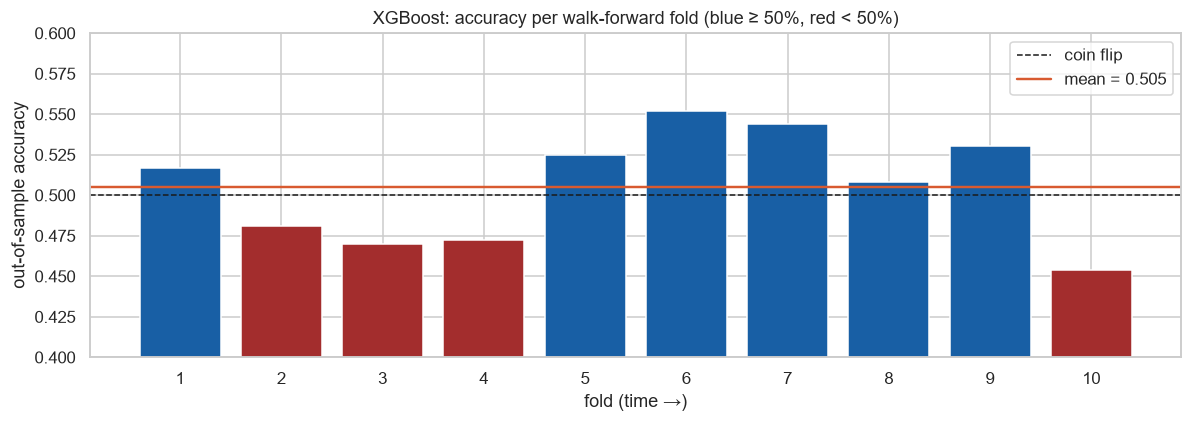

In [5]:
best="XGBoost"
fa=per_fold[per_fold.model==best].sort_values("fold")
fig,ax=plt.subplots(figsize=(11,4))
ax.bar(fa["fold"],fa["accuracy"],
       color=["#185FA5" if a>=0.5 else "#A32D2D" for a in fa["accuracy"]])
ax.axhline(0.5,color="k",lw=1,ls="--",label="coin flip")
ax.axhline(fa["accuracy"].mean(),color="#D85A30",lw=1.6,label=f"mean = {fa['accuracy'].mean():.3f}")
ax.set_ylim(0.40,0.60); ax.set_xticks(fa["fold"])
ax.set_xlabel("fold (time →)"); ax.set_ylabel("out-of-sample accuracy")
ax.set_title(f"{best}: accuracy per walk-forward fold (blue ≥ 50%, red < 50%)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"walkforward_accuracy.png",bbox_inches="tight"); plt.show()

## Walk-forward backtest (the multi-window one the methodology asked for)

Now the real test the README promised: turn the stitched out-of-sample predictions into a strategy and
charge the same 0.1% cost, over the **whole** out-of-sample span rather than one window. The vol-scaled
variant reuses the GARCH risk engine; its volatility target is taken from the **initial training pool
only**, so it's leakage-free across the entire span.

In [6]:
COST=0.001; TRADING_DAYS=365
have_vol="garch_vol" in df.columns
cols=["date","target_return"]+(["garch_vol"] if have_vol else [])
bt=oos.merge(df[cols],on="date",how="left")

def run(pos):
    pos=np.asarray(pos,float); r=bt["target_return"].values
    turn=np.abs(np.diff(np.concatenate([[0],pos])))
    strat=pos*r-COST*turn; eq=np.exp(np.cumsum(strat))
    ann=strat.mean()*TRADING_DAYS; vol=strat.std()*np.sqrt(TRADING_DAYS)
    dd=(eq/np.maximum.accumulate(eq)-1).min()
    return eq,{"total_return":eq[-1]-1,"sharpe":ann/vol if vol>0 else np.nan,
               "max_drawdown":dd,"trades":int((turn>0).sum())}

defs={"Buy & Hold":np.ones(len(bt)),
      "XGBoost long/flat":bt["pred_XGBoost"].values}
if have_vol:
    target_vol=df["garch_vol"].iloc[:min_train].median()      # pre-OOS => leakage-free for whole span
    vol_mult=np.clip(target_vol/bt["garch_vol"].values,0,1.0)
    defs["XGBoost vol-scaled"]=bt["pred_XGBoost"].values*vol_mult
    print(f"Vol-scaling target (initial-pool median garch_vol): {target_vol:.2f}")

curves={}; rows=[]
for name,pos in defs.items():
    eq,mt=run(pos); curves[name]=eq; mt["strategy"]=name; rows.append(mt)
wf_bt=pd.DataFrame(rows).set_index("strategy")
wf_bt.round(4).to_csv(TAB/"walkforward_backtest.csv")
bh=wf_bt.loc["Buy & Hold","total_return"]
beat=[s for s in wf_bt.index if s!="Buy & Hold" and wf_bt.loc[s,"total_return"]>bh]
print("Beat Buy & Hold over the full OOS span:", beat if beat else "none")
wf_bt.round(4)

Vol-scaling target (initial-pool median garch_vol): 4.44
Beat Buy & Hold over the full OOS span: none


,total_return,sharpe,max_drawdown,trades
strategy,,,,
Buy & Hold,0.6485,0.1875,-0.7663,1
XGBoost long/flat,0.3754,0.1236,-0.7776,233
XGBoost vol-scaled,0.4201,0.1405,-0.7626,568


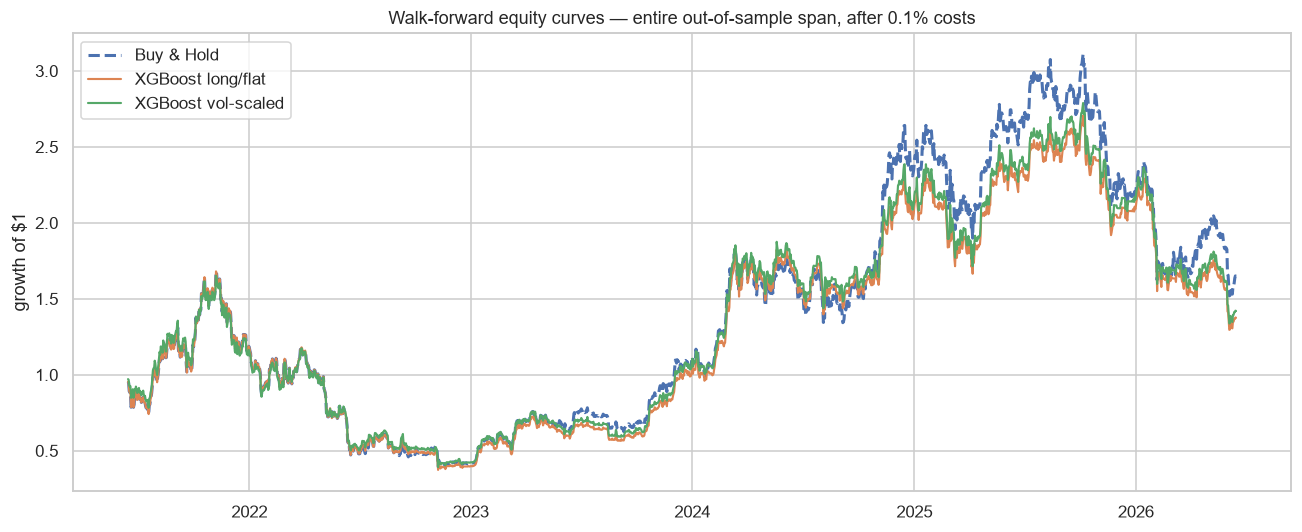

In [7]:
fig,ax=plt.subplots(figsize=(12,5))
for name,eq in curves.items():
    s="--" if name=="Buy & Hold" else "-"; lw=2 if name=="Buy & Hold" else 1.4
    ax.plot(bt["date"],eq,s,lw=lw,label=name)
ax.set_title("Walk-forward equity curves — entire out-of-sample span, after 0.1% costs")
ax.set_ylabel("growth of $1"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"walkforward_equity.png",bbox_inches="tight"); plt.show()

## Takeaway

This is the check that upgrades the project's headline from *"51% on one window"* to *"51% that
holds up when the window is moved through time."* Read it honestly:

- If fold accuracies scatter around 0.50 and both the binomial and t-tests come back non-significant,
  the single-split result was **not a fluke** — near-random direction is the real, robust finding.
- If a strategy only beat buy-and-hold on the original window but not across the walk-forward, that
  original outperformance was **window luck**, exactly the caveat the methodology flagged.
- If (unexpectedly) the edge *did* persist across most folds and survive costs, *now* it's worth
  taking seriously — because it cleared the bar that kills most "predicts crypto" claims.

Either way, the contribution is the same: an edge is only believed once it survives being tested
out-of-sample many times over. Tables in `outputs/10_walkforward/tables/`, figures in `.../figures/`;
stitched predictions saved to `data/processed/predictions_walkforward.csv`.